In [1]:
import pandas  as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
df=files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [9]:
df=df.dropna()

In [10]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [11]:
df.groupby('Contract')['Churn'].value_counts()

Contract        Churn
Month-to-month  0        2220
                1        1655
One year        0        1306
                1         166
Two year        0        1637
                1          48
Name: count, dtype: int64

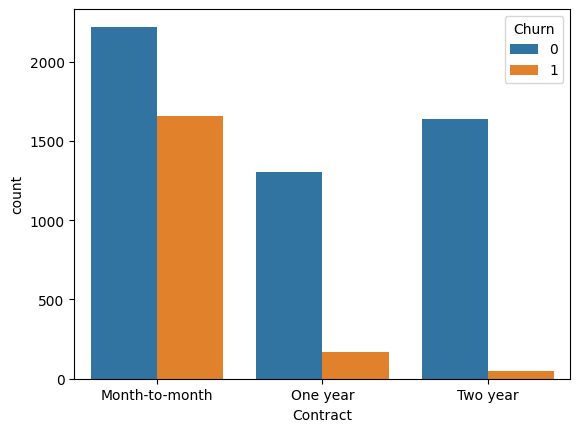

In [12]:
sns.countplot(x='Contract',hue='Churn',data=df)
plt.show()

In [13]:
df.groupby('tenure')['Churn'].value_counts()

tenure  Churn
1       1        380
        0        233
2       1        123
        0        115
3       0        106
                ... 
70      1         11
71      0        164
        1          6
72      0        356
        1          6
Name: count, Length: 144, dtype: int64

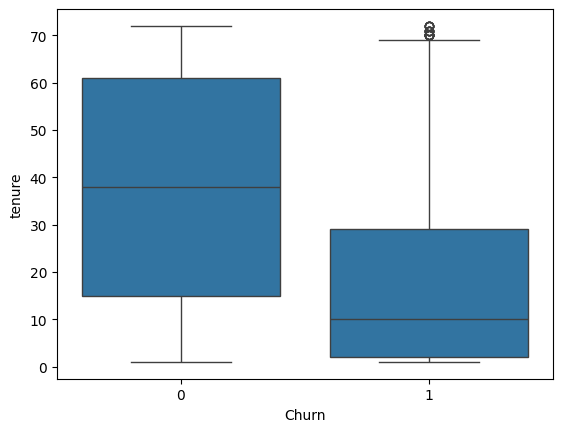

In [14]:
sns.boxplot(x='Churn',y='tenure',data=df)
plt.show()

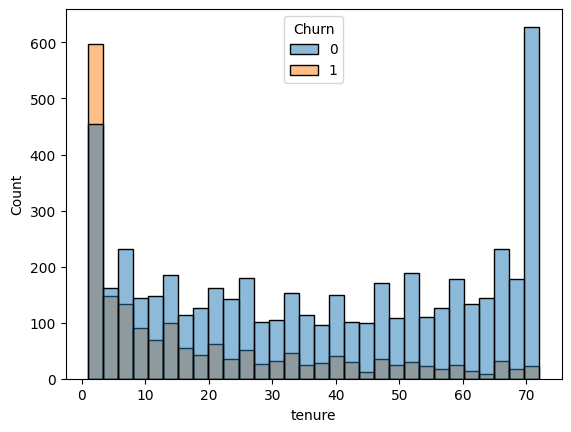

In [15]:
sns.histplot( x='tenure', hue='Churn',data=df, bins=30)
plt.show()

In [16]:
df.groupby('MonthlyCharges')['Churn'].value_counts()

,,count
MonthlyCharges,Churn,
18.25,0,1
18.40,0,1
18.55,0,1
18.70,0,2
18.75,0,1
...,...,...
118.20,0,1
118.35,1,1
118.60,0,2


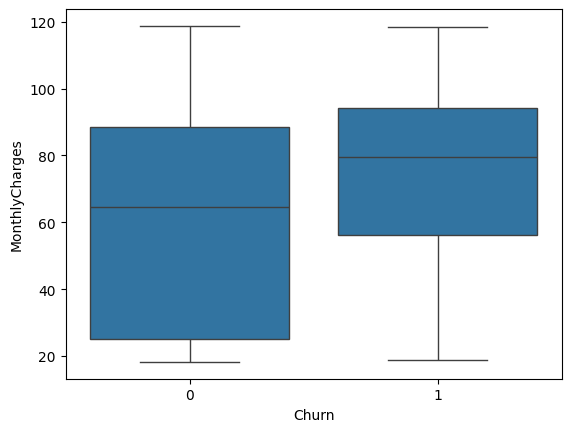

In [17]:
sns.boxplot(x='Churn',y='MonthlyCharges',data=df)
plt.show()

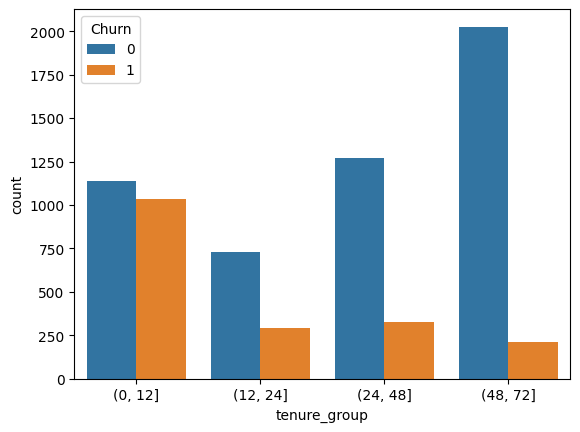

In [18]:
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,48,72])
sns.countplot(x='tenure_group', hue='Churn', data=df)
plt.show()

In [19]:
df.groupby('tenure_group')['Churn'].value_counts(normalize=True).unstack()

/tmp/ipykernel_674/1156904118.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('tenure_group')['Churn'].value_counts(normalize=True).unstack()


Churn,0,1
tenure_group,,
"(0, 12]",0.523218,0.476782
"(12, 24]",0.712891,0.287109
"(24, 48]",0.796110,0.203890
"(48, 72]",0.904868,0.095132


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [21]:
df=df.drop('customerID',axis=1)

In [29]:
X=df.drop("Churn",axis=1)
y=df["Churn"]
X = pd.get_dummies(X, drop_first=True)

In [30]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [95]:
log_reg=LogisticRegression(max_iter=5000)
log_reg.fit(X_train,y_train)

LogisticRegression(max_iter=5000)

In [96]:
logY_pred=log_reg.predict(X_test)
logY_pred

array([0, 0, 1, ..., 0, 0, 0])

In [106]:
df['log_riskscore']=log_reg.predict_proba(X)[:,1]
y_pred=(df['log_riskscore']>0.3).astype(int)
df['log_riskscore']

,log_riskscore
0,0.651939
1,0.035139
2,0.308333
3,0.023025
4,0.710396
...,...
7038,0.073864
7039,0.130365
7040,0.391558
7041,0.743400


In [107]:
df.sort_values(by='log_riskscore',ascending=False).head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,log_riskscore
2208,0,1,1,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,100.80,100.80,1,"(0, 12]",0.893037
3380,1,1,1,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,95.10,95.10,1,"(0, 12]",0.889624
1976,1,1,0,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,93.55,93.55,1,"(0, 12]",0.885116
4800,1,1,0,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,94.00,94.00,1,"(0, 12]",0.884726
1410,0,1,0,No,2,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,93.85,170.85,1,"(0, 12]",0.882558
5989,1,1,1,No,3,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,94.60,279.55,1,"(0, 12]",0.880842
3749,1,1,0,No,2,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,93.85,196.75,1,"(0, 12]",0.880360
6368,1,1,0,No,2,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,94.00,181.70,1,"(0, 12]",0.879923
3159,1,1,0,No,3,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,94.85,335.75,0,"(0, 12]",0.875505
997,0,1,0,No,4,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,94.30,424.45,1,"(0, 12]",0.873819


In [108]:
print("Logistic Regression:\n", classification_report(y_test, logY_pred))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



In [109]:
print(accuracy_score(y_test,logY_pred))

0.7889125799573561


In [119]:
rand_for=RandomForestClassifier(n_estimators=400,min_samples_split=5,max_depth=10,min_samples_leaf=2)
rand_for.fit(X_train,y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=400)

In [120]:
randY=rand_for.predict(X_test)
randY

array([0, 0, 1, ..., 0, 0, 0])

In [131]:
y_prob=rand_for.predict_proba(X_test)[:,1]
y_pred2=(y_prob>0.4).astype(int)
df["risk_score2"]

,risk_score2
0,0.560207
1,0.050685
2,0.493539
3,0.044477
4,0.661012
...,...
7038,0.136688
7039,0.147647
7040,0.347386
7041,0.722455


In [132]:
print("Random Forest Classifier:\n",classification_report(y_test,randY))

Random Forest Classifier:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.66      0.48      0.56       374

    accuracy                           0.80      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.80      0.78      1407



In [133]:
print(accuracy_score(y_test,randY))

0.7960199004975125


In [136]:
danzer_zone=df[(df['Contract'] == 'Month-to-month') & (df['tenure'] < 10) & (df['MonthlyCharges'] > 80)]
len(danzer_zone)

378

In [137]:
average_risk=danzer_zone['log_riskscore'].mean()
average_risk

np.float64(0.7321193855790028)

In [141]:
high_risk=df[df["log_riskscore"]>0.75]
len(high_risk)

331

In [146]:
from google.colab import files
df.to_csv('telco_churn_analysis.csv', index=False)
files.download('telco_churn_analysis.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>